<a href="https://colab.research.google.com/github/Hashhhhhhhh/Quantum-Optimization/blob/main/Optimization_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's consider a 2D loss function with many locaal minima using different optimization methods.

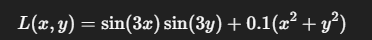

In [2]:
import numpy as np
import matplotlib.pyplot as plt

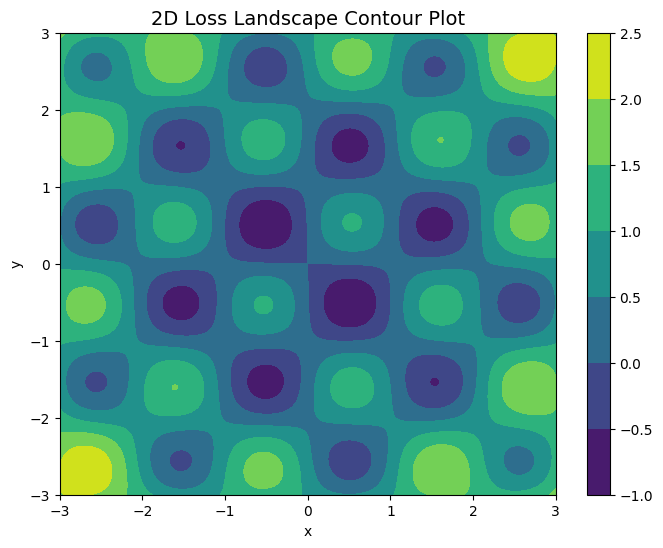

In [10]:
#defining loss function
def loss_func(x,y):
  return np.sin(3*x)*np.sin(3*y)+0.1*(x**2 + y**2)
#creating a grid for contour plot
x=np.linspace(-3,3,500)
y=np.linspace(-3,3,500)
X,Y=np.meshgrid(x,y)
Z = loss_func(X, Y)
#plotting
fig, ax = plt.subplots(figsize=(8, 6))
contours = ax.contourf(X, Y, Z,cmap='viridis')
ax.set_title("2D Loss Landscape Contour Plot", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.colorbar(contours)
plt.show()


In [23]:
def grad_L(x, y):
  # partial derivatives computed analytically:
    # d/dx [sin(3x) sin(3y)] = 3 cos(3x) sin(3y)
    # d/dx [0.1 x^2] = 0.2 x
  gx = 3*np.cos(3*x)*np.sin(3*y) + 0.2*x
  gy = 3*np.cos(3*y)*np.sin(3*x) + 0.2*y
  return gx, gy

In [20]:
def gradient_descent(x0, y0, lr=0.05, steps=300):
   #lr: learning rate
   # Initialize trajectory lists with starting point
   xs,ys=[x0],[y0]
   x,y=x0,y0
   for t in range(steps):
        gx, gy = grad_L(x, y)
        x = x - lr * gx
        y = y - lr * gy
        xs.append(x); ys.append(y)
   return np.array(xs), np.array(ys)

In [17]:
def adam(x0, y0, lr=0.05, steps=300, beta1=0.9, beta2=0.999, eps=1e-8):
    xs, ys = [x0], [y0]
    x, y = x0, y0
    m_x, v_x = 0.0, 0.0
    m_y, v_y = 0.0, 0.0
    for t in range(1, steps+1):
        gx, gy = grad_L(x, y)
        # x
        m_x = beta1*m_x + (1-beta1)*gx
        v_x = beta2*v_x + (1-beta2)*(gx*gx)
        m_x_hat = m_x / (1 - beta1**t)
        v_x_hat = v_x / (1 - beta2**t)
        x = x - lr * m_x_hat / (np.sqrt(v_x_hat) + eps)
        # y
        m_y = beta1*m_y + (1-beta1)*gy
        v_y = beta2*v_y + (1-beta2)*(gy*gy)
        m_y_hat = m_y / (1 - beta1**t)
        v_y_hat = v_y / (1 - beta2**t)
        y = y - lr * m_y_hat / (np.sqrt(v_y_hat) + eps)
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

In [28]:
def quantum_tunneling(x0, y0, steps=300, step_size=0.03, jump_prob=0.05, tunneling_tau=0.3):
    """
    A 'quantum-inspired' optimizer:
      - normally takes a small gradient-step-like move (we combine small gradient + noise)
      - with probability `jump_prob` proposes a random jump; accepts based on exp(-dE/tau)
    """
    xs, ys = [x0], [y0]
    x, y = x0, y0
    for t in range(steps):
        # small gradient step + gaussian noise (to give diffusion)
        gx, gy = grad_L(x, y)
        x_prop = x - 0.02 * gx + np.random.normal(scale=step_size)
        y_prop = y - 0.02 * gy + np.random.normal(scale=step_size)

        # occasionally propose a larger random jump (simulate tunneling attempt)
        if np.random.rand() < jump_prob:
            # propose jump from local well: wider gaussian
            x_jump = x + np.random.normal(scale=0.6)
            y_jump = y + np.random.normal(scale=0.6)
            E_current = loss_func(x, y)
            E_jump = loss_func(x_jump, y_jump)
            dE = E_jump - E_current
            # accept if lower or sometimes accept uphill according to tunneling_tau
            if dE <= 0 or np.random.rand() < np.exp(-dE / tunneling_tau):
                x_prop, y_prop = x_jump, y_jump

        # accept the normal proposal if it lowers energy, or accept with small prob (thermal-like)
        E_current = loss_func(x, y)
        E_prop = loss_func(x_prop, y_prop)
        if E_prop <= E_current or np.random.rand() < np.exp(-(E_prop - E_current) / (tunneling_tau*0.5)):
            x, y = x_prop, y_prop
        # else keep x,y unchanged

        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

In [31]:
# ---------- 3) Run all optimizers from the same initial point ----------
x0, y0 = -2.5, 2.0   # choose an interesting starting point
steps = 700

gd_x, gd_y = gradient_descent(x0, y0, lr=0.05, steps=steps)
adam_x, adam_y = adam(x0, y0, lr=0.06, steps=steps)
qt_x, qt_y = quantum_tunneling(x0, y0, steps=steps, step_size=0.05, jump_prob=0.06, tunneling_tau=0.35)

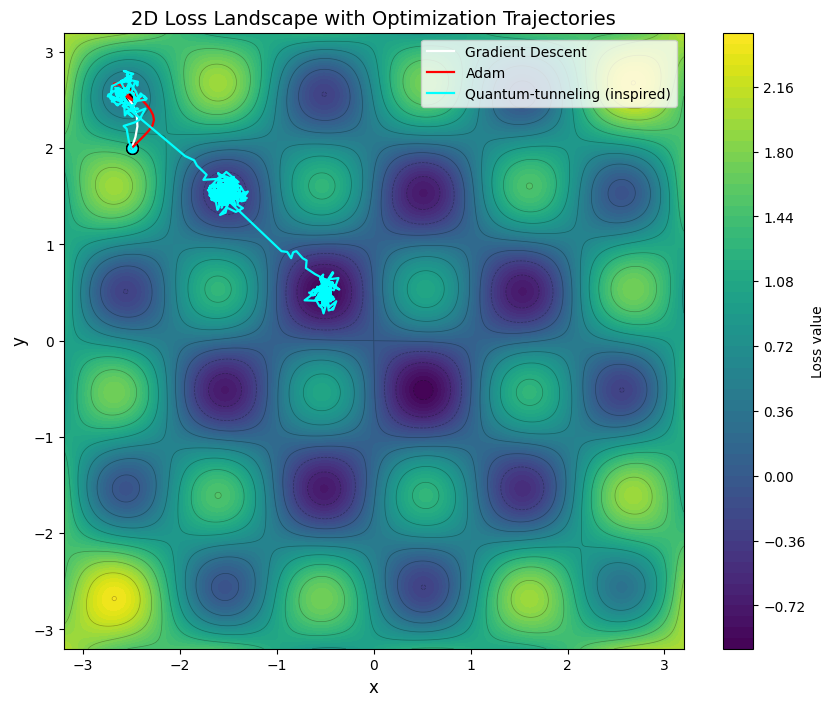

Final positions and losses:
GD    -> (x,y) = (-2.5599, 2.5599), L = 0.3407
Adam  -> (x,y) = (-2.5599, 2.5599), L = 0.3407
Quant -> (x,y) = (-0.5142, 0.4795), L = -0.9414


In [33]:
# ---------- 4) Make contour plot and overlay trajectories ----------
# grid for contour
xs_grid = np.linspace(-3.2, 3.2, 500)
ys_grid = np.linspace(-3.2, 3.2, 500)
X, Y = np.meshgrid(xs_grid, ys_grid)
Z = loss_func(X, Y)

fig, ax = plt.subplots(figsize=(10, 8))
# filled contour
cf = ax.contourf(X, Y, Z, levels=60, cmap='viridis')
# contour lines for structure
ax.contour(X, Y, Z, levels=12, linewidths=0.5, colors='k', alpha=0.3)

# overlay trajectories
ax.plot(gd_x, gd_y, '-', linewidth=1.6, label='Gradient Descent', color='white')
ax.scatter(gd_x[0], gd_y[0], marker='o', color='white', edgecolor='black', s=70)   # start
ax.scatter(gd_x[-1], gd_y[-1], marker='X', color='white', edgecolor='black', s=80) # end

ax.plot(adam_x, adam_y, '-', linewidth=1.6, label='Adam', color='red')
ax.scatter(adam_x[0], adam_y[0], marker='o', color='red', edgecolor='black', s=70)
ax.scatter(adam_x[-1], adam_y[-1], marker='X', color='red', edgecolor='black', s=80)

ax.plot(qt_x, qt_y, '-', linewidth=1.6, label='Quantum-tunneling (inspired)', color='cyan')
ax.scatter(qt_x[0], qt_y[0], marker='o', color='cyan', edgecolor='black', s=70)
ax.scatter(qt_x[-1], qt_y[-1], marker='X', color='cyan', edgecolor='black', s=80)

ax.set_xlim([-3.2, 3.2])
ax.set_ylim([-3.2, 3.2])
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("2D Loss Landscape with Optimization Trajectories", fontsize=14)

# colorbar and legend
plt.colorbar(cf, ax=ax, label="Loss value")
ax.legend(loc='upper right')
plt.show()

# ---------- 5) quick printout of final positions and losses ----------
print("Final positions and losses:")
print("GD    -> (x,y) = ({:.4f}, {:.4f}), L = {:.4f}".format(gd_x[-1], gd_y[-1], loss_func(gd_x[-1], gd_y[-1])))
print("Adam  -> (x,y) = ({:.4f}, {:.4f}), L = {:.4f}".format(adam_x[-1], adam_y[-1], loss_func(adam_x[-1], adam_y[-1])))
print("Quant -> (x,y) = ({:.4f}, {:.4f}), L = {:.4f}".format(qt_x[-1], qt_y[-1], loss_func(qt_x[-1], qt_y[-1])))